Importing The Dependencies

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [135]:
# load the dataset file onto a pandas DataFrame
df = pd.read_csv("../dataset/raw data/credit_risk_dataset.csv")

In [136]:
# print the first 5 rows of the dataset
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [137]:
# displays the number of rows and columns
df.shape

(32581, 12)

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [139]:
# converting the object data type into string data type and removed the  trimmed spaces and standardized it

# Group columns by type 
category_cols = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']
num_cols = ['person_emp_length','loan_int_rate']

for cols in category_cols:
    df[cols] = df[cols].astype("string").str.strip().str.lower()

In [140]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [141]:
df.dtypes

person_age                             int64
person_income                          int64
person_home_ownership         string[python]
person_emp_length                    float64
loan_intent                   string[python]
loan_grade                    string[python]
loan_amnt                              int64
loan_int_rate                        float64
loan_status                            int64
loan_percent_income                  float64
cb_person_default_on_file     string[python]
cb_person_cred_hist_length             int64
dtype: object

In [142]:
# to find the number of duplicated values
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# Display a few duplicates to inpect them
if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].sort_values(by='person_income'))

# Drop them and keep the first occurence
df = df.drop_duplicates(keep='first')
print("Duplicates handled sucessfully")

Number of duplicate rows found: 165


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
16821,24,7800,rent,1.0,education,b,1000,11.36,0,0.13,n,4
15952,24,7800,rent,1.0,education,b,1000,11.36,0,0.13,n,4
15944,21,8088,rent,NaN,medical,c,1200,15.23,0,0.15,y,2
16835,21,8088,rent,NaN,medical,c,1200,15.23,0,0.15,y,2
2471,24,10000,rent,8.0,personal,a,3000,7.90,1,0.30,n,3
...,...,...,...,...,...,...,...,...,...,...,...,...
238,22,183000,mortgage,3.0,education,a,1000,NaN,0,0.01,n,2
32047,36,250000,rent,2.0,debtconsolidation,a,20000,7.88,0,0.08,n,17
29160,36,250000,rent,2.0,debtconsolidation,a,20000,7.88,0,0.08,n,17
28770,28,604000,mortgage,12.0,personal,b,25000,9.01,1,0.04,n,9


Duplicates handled sucessfully


In [143]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [144]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,rent,123.0,personal,d,35000,16.02,1,0.59,y,3
1,21,9600,own,5.0,education,b,1000,11.14,0,0.10,n,2
2,25,9600,mortgage,1.0,medical,c,5500,12.87,1,0.57,n,3
3,23,65500,rent,4.0,medical,c,35000,15.23,1,0.53,n,2
4,24,54400,rent,8.0,medical,c,35000,14.27,1,0.55,y,4


In [145]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,31529.00000,32416.000000,29321.000000,32416.000000,32416.000000,32416.000000
mean,27.747008,6.609164e+04,4.79051,9593.845632,11.017265,0.218688,0.170250,5.811297
std,6.354100,6.201558e+04,4.14549,6322.730241,3.241680,0.413363,0.106812,4.059030
min,20.000000,4.000000e+03,0.00000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.854200e+04,2.00000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.00000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.921800e+04,7.00000,12250.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.00000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [146]:
# checking if there is any negative value in columns 
cols_to_check = ['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_status','loan_percent_income','cb_person_cred_hist_length']

negative_rows = (df[cols_to_check] <0).any(axis=1).sum()

if negative_rows > 0:
    print(f"Number of rows with negative values : {negative_rows} ")
else:
    print(f"There is no rows with negative values.")


There is no rows with negative values.


In [147]:
# check if people have realistic age
count_of_age_greater_110 = (df['person_age'] > 110).sum()
if count_of_age_greater_110 > 0:
    print(f"Number of rows where people have unrealistic age {count_of_age_greater_110}.")
else:
    print(f"There is no rows with people having unrealistic age.")

Number of rows where people have unrealistic age 5.


In [148]:
age_outlier = df[df['person_age']> 110].index
df = df.drop(age_outlier)

print(f"Dropped {len(age_outlier)} row with unrealistic ages.")

Dropped 5 row with unrealistic ages.


In [149]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3094
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [150]:
# Replacing the empty or null values
category_cols = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']
num_cols = ['person_emp_length','loan_int_rate']

# Replace empty category values with "Unknown" value
df[category_cols] = df[category_cols].fillna("Unknown")

# Replace empty numerical values with Median 
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Drop target column (loan_status) with missing values
df = df.dropna(subset = ['loan_status'])

In [151]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [152]:
# checking people who are working longer than they've been alive 
logic_error_count = (df['person_emp_length'] > df['person_age'] ).sum()
if logic_error_count > 0:
    print(f"Number of rows where Employment length is greater than the person's age : {logic_error_count}.")
    df = df[df['person_emp_length'] <= df['person_age']]

Number of rows where Employment length is greater than the person's age : 2.


In [153]:
emp_length_outlier = df[df['person_emp_length'] > df['person_age']].index
df = df.drop(emp_length_outlier)

print(f"Dropped {len(emp_length_outlier)} rows with Employment Length is greater than Person's Age.")

Dropped 0 rows with Employment Length is greater than Person's Age.


While I was checking and exploring the data to find any outliers or uncertainties, I found two logical inconsistencies: unrealistic or impossible age of the person (above 110) and employment length greater than their age.So, I dropped them so that there won't be any bias in the model.

In [154]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32409.000000,3.240900e+04,32409.000000,32409.000000,32409.000000,32409.000000,32409.000000,32409.000000
mean,27.730754,6.589428e+04,4.761424,9592.486655,11.014512,0.218705,0.170248,5.811194
std,6.210445,5.251787e+04,3.983757,6320.885127,3.083104,0.413374,0.106785,4.057899
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12250.000000,13.110000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [155]:
# export and save clean dataset
df.to_csv("../dataset/cleaned data/clean_credit_risk_dataset.csv", index=False)

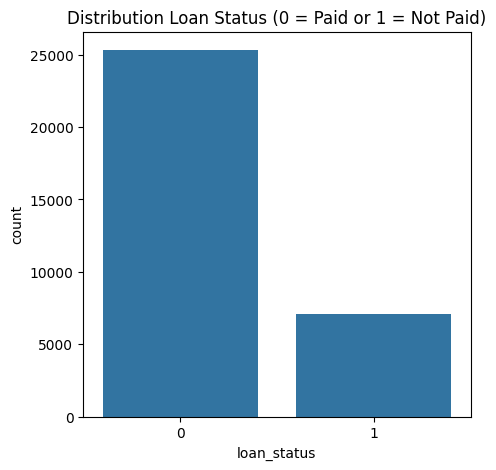

loan_status
0    25321
1     7088
Name: count, dtype: int64

In [156]:
# display the loan_status in barplot
plt.figure(figsize=(5,5))
sns.countplot(x='loan_status', data=df)
plt.title('Distribution Loan Status (0 = Paid or 1 = Not Paid)')
plt.show()

# display the numiercal count of loan_status
df['loan_status'].value_counts()

0 -> Paid

1 -> Not Paid

In [157]:
# print the percentage of loan_staus values
print(df['loan_status'].value_counts(normalize=True) * 100)

loan_status
0    78.129532
1    21.870468
Name: proportion, dtype: float64


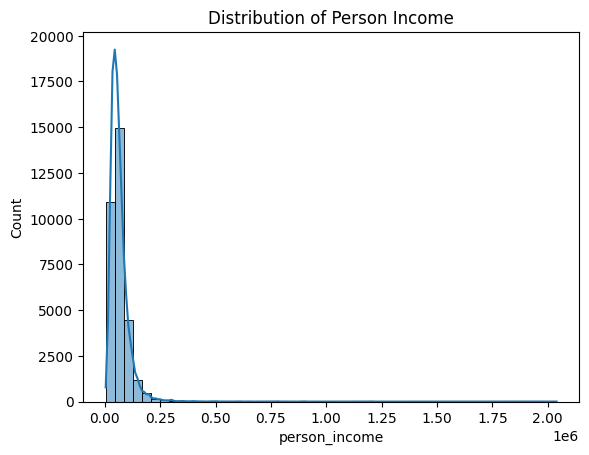

In [158]:
# look at the distribution of the income 
sns.histplot(df['person_income'],bins=50, kde=True)
plt.title('Distribution of Person Income')
plt.show()

In [ ]:
# display the correlation of numeric features

plt.figure(figsize=(10,4))

# Correlation must always be numeric columns 
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Numeric Features")
plt.show()